# RoBERTa Prompt PCL Detection (Local)
Local notebook aligned to the 
current `deberta-prompt-pcl-kaggle.ipynb` prompt approach:
- prompt-based cloze classification with `[MASK]`
- multi-word verbalizer
- hard oversampling (8x positives)
- custom trainer save for tied MLM weights
Additionally, this local version concatenates `keyword` and `country` into the prompted input text.


In [1]:
!pip install contractions python-dotenv huggingface_hub


In [ ]:
import os
import re
import random
import inspect

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



/home/wowthecoder/imperial-nlp-cw/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'dont_patronize_me'

In [ ]:
def load_task1(train_path: str) -> pd.DataFrame:
    """
    Load Task 1 data and convert original labels to binary:
      0/1 -> 0 (No-PCL)
      2/3/4 -> 1 (PCL)
    """
    rows = []
    with open(train_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue

            par_id = parts[0]
            art_id = parts[1]
            keyword = parts[2]
            country = parts[3]
            text = parts[4]
            orig_label = parts[-1]
            label = 0 if orig_label in {'0', '1'} else 1

            rows.append(
                {
                    'par_id': str(par_id),
                    'art_id': art_id,
                    'keyword': keyword,
                    'country': country,
                    'text': text,
                    'label': label,
                    'orig_label': orig_label,
                }
            )

    return pd.DataFrame(
        rows,
        columns=['par_id', 'art_id', 'keyword', 'country', 'text', 'label', 'orig_label'],
    )

In [ ]:
# Local auth: load Hugging Face token from .env
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print('HF token loaded from .env and login completed.')
else:
    print('HF_TOKEN not found in .env; proceeding without explicit login.')


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded from .env and login completed.


In [ ]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME = 'roberta-base'
RUN_NAME = 'checkpoints/roberta_base'
MAX_LENGTH = 256

VERBALIZER = {
    0: ['no', 'false', 'never', 'neither'],
    1: ['yes', 'okay', 'true', 'surely'],
}

PROMPT_TEMPLATE = '{text} Is it patronizing or condescending? {mask}'

DATA_ROOT = '..'
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')

OUTPUT_DIR = 'checkpoints/roberta_base_prompt_local'
LOG_DIR = 'logs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print(f'DATA_ROOT   : {DATA_ROOT}')
print(f'OUTPUT_DIR  : {OUTPUT_DIR}')


DATA_ROOT   : .
OUTPUT_DIR  : checkpoints/roberta_base_prompt_local


In [ ]:
# ============================================================
# Load + preprocess data (local module)
# ============================================================
df = load_task1()


def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    # text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(preprocess_text)

df['keyword'] = df['keyword'].fillna('').astype(str)
df['country'] = df['country'].fillna('').astype(str)
df['model_text'] = (
    df['keyword'].str.strip()
    + ' </s> '
    + df['country'].str.strip()
    + ' </s> '
    + df['clean_text'].str.strip()
)

print(f'Loaded dataset: {len(df):,} samples')
print(df['label'].value_counts().sort_index().rename({0: 'No-PCL', 1: 'PCL'}))
assert set(df['label'].unique()).issubset({0, 1})


Loaded dataset: 10,469 samples
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [ ]:
# ============================================================
# Official Train/Dev split + hard oversampling (8x positives)
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df = pd.read_csv(DEV_IDS_PATH, dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids = set(dev_ids_df['par_id'].astype(str))

train_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)
dev_df = df[df['par_id'].isin(dev_par_ids)].copy().reset_index(drop=True)

leftover_df = df[~df['par_id'].isin(train_par_ids | dev_par_ids)].copy().reset_index(drop=True)
if len(leftover_df) > 0:
    train_df = pd.concat([train_df, leftover_df], ignore_index=True)
    print(f'Appended {len(leftover_df):,} unassigned samples to training set.')


def describe_split(name: str, frame: pd.DataFrame):
    n = len(frame)
    n_pcl = int((frame['label'] == 1).sum())
    n_no_pcl = int((frame['label'] == 0).sum())
    ratio = f'1:{(n_no_pcl / n_pcl):.1f}' if n_pcl > 0 else 'undefined'
    print(f'{name:<16} -> total={n:,} | PCL={n_pcl:,} | No-PCL={n_no_pcl:,} | ratio={ratio}')


describe_split('Train (before OS)', train_df)
describe_split('Dev', dev_df)

replicated_pcls = pd.concat([train_df[train_df['label'] == 1]] * 8, ignore_index=True)
train_df = pd.concat([train_df, replicated_pcls], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

describe_split('Train (after OS)', train_df)


Train (before OS) -> total=8,375 | PCL=794 | No-PCL=7,581 | ratio=1:9.5
Dev              -> total=2,094 | PCL=199 | No-PCL=1,895 | ratio=1:9.5
Train (after OS) -> total=14,727 | PCL=7,146 | No-PCL=7,581 | ratio=1:1.1


In [ ]:
# ============================================================
# Tokenization with prompt wrapping + Hugging Face Datasets
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MASK_TOKEN = tokenizer.mask_token
MASK_TOKEN_ID = tokenizer.mask_token_id
print(f'Mask token: {MASK_TOKEN!r}  (id={MASK_TOKEN_ID})')


def resolve_verbalizer_ids(tokenizer, verbalizer):
    class_ids = {}
    for label_idx in sorted(verbalizer.keys()):
        ids = []
        for word in verbalizer[label_idx]:
            tokens = tokenizer.encode(' ' + word, add_special_tokens=False)
            tok_id = tokens[0]
            n = len(tokens)
            tag = 'single' if n == 1 else f'multi({n})'
            print(f'  Class {label_idx} -> "{word}" -> id {tok_id}  [{tag}]')
            ids.append(tok_id)
        class_ids[label_idx] = ids
    return class_ids


print('\nVerbalizer token IDs:')
VERBALIZER_IDS = resolve_verbalizer_ids(tokenizer, VERBALIZER)
print(f'Resolved: {VERBALIZER_IDS}')


def build_prompt(text, mask_token):
    return PROMPT_TEMPLATE.format(text=text, mask=mask_token)


_demo = build_prompt('homeless </s> gb </s> These poor children really need our help', MASK_TOKEN)
print(f'\nExample prompt:\n{_demo}')
print(f'Tokens: {len(tokenizer(_demo)["input_ids"])}')


def add_prompt_column(frame):
    frame = frame.copy()
    frame['prompted_text'] = frame['model_text'].apply(lambda t: build_prompt(t, MASK_TOKEN))
    return frame


train_prompted = add_prompt_column(train_df)
dev_prompted = add_prompt_column(dev_df)

train_hf = Dataset.from_pandas(
    train_prompted[['prompted_text', 'label']].rename(columns={'prompted_text': 'text'}),
    preserve_index=False,
)
dev_hf = Dataset.from_pandas(
    dev_prompted[['prompted_text', 'label']].rename(columns={'prompted_text': 'text'}),
    preserve_index=False,
)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


train_ds = train_hf.map(tokenize, batched=True, remove_columns=['text'])
dev_ds = dev_hf.map(tokenize, batched=True, remove_columns=['text'])

train_ds = train_ds.rename_column('label', 'labels')
dev_ds = dev_ds.rename_column('label', 'labels')

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dev_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'\nTrain: {train_ds}')
print(f'Dev:   {dev_ds}')


Mask token: '<mask>'  (id=50264)

Verbalizer token IDs:
  Class 0 -> "no" -> id 117  [single]
  Class 0 -> "false" -> id 3950  [single]
  Class 0 -> "never" -> id 393  [single]
  Class 0 -> "neither" -> id 5063  [single]
  Class 1 -> "yes" -> id 4420  [single]
  Class 1 -> "okay" -> id 8578  [single]
  Class 1 -> "true" -> id 1528  [single]
  Class 1 -> "surely" -> id 8349  [single]
Resolved: {0: [117, 3950, 393, 5063], 1: [4420, 8578, 1528, 8349]}

Example prompt:
homeless </s> gb </s> These poor children really need our help Is it patronizing or condescending? <mask>
Tokens: 26


Map: 100%|██████████| 2094/2094 [00:00<00:00, 27634.30 examples/s]


Train: Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 14727
})
Dev:   Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2094
})


In [ ]:
# ============================================================
# Metrics (handles log-prob outputs from prompt model)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
    }


In [ ]:
# ============================================================
# Model: Prompt-based DeBERTa with multi-word verbalizer
# ============================================================
class PromptMLMClassifier(nn.Module):
    def __init__(self, model_name, verbalizer_ids, mask_token_id):
        super().__init__()
        self.mlm = AutoModelForMaskedLM.from_pretrained(model_name)
        self.verbalizer_ids = verbalizer_ids
        self.mask_token_id = mask_token_id
        self.num_classes = len(verbalizer_ids)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.mlm(input_ids=input_ids, attention_mask=attention_mask)
        vocab_logits = outputs.logits

        mask_flags = (input_ids == self.mask_token_id)
        mask_pos = mask_flags.long().argmax(dim=-1)

        batch_size = input_ids.shape[0]
        batch_idx = torch.arange(batch_size, device=input_ids.device)
        mask_logits = vocab_logits[batch_idx, mask_pos, :]

        mask_probs = torch.softmax(mask_logits, dim=-1)

        class_probs = []
        for cls_idx in sorted(self.verbalizer_ids.keys()):
            word_ids = torch.tensor(self.verbalizer_ids[cls_idx], device=input_ids.device, dtype=torch.long)
            cls_prob = mask_probs[:, word_ids].mean(dim=-1)
            class_probs.append(cls_prob)

        class_probs = torch.stack(class_probs, dim=-1)
        log_probs = torch.log(class_probs + 1e-10)

        loss = None
        if labels is not None:
            loss = F.nll_loss(log_probs, labels)

        return SequenceClassifierOutput(loss=loss, logits=log_probs)


model = PromptMLMClassifier(
    model_name=MODEL_NAME,
    verbalizer_ids=VERBALIZER_IDS,
    mask_token_id=MASK_TOKEN_ID,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

training_args = TrainingArguments(
    RUN_NAME,
    num_train_epochs=2,
    save_total_limit=2,
    learning_rate=1e-5,
    eval_strategy='epoch',
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=1,
    warmup_steps=2000,
    lr_scheduler_type='cosine',
    weight_decay=0.01,
    report_to='none',
    seed=SEED,
)


class PromptTrainer(Trainer):
    def _save(self, output_dir=None, state_dict=None):
        # Save inner MLM model to avoid tied-weight safetensors errors.
        output_dir = output_dir if output_dir is not None else self.args.output_dir
        os.makedirs(output_dir, exist_ok=True)

        unwrapped = self.model
        if hasattr(unwrapped, 'module'):
            unwrapped = unwrapped.module

        unwrapped.mlm.save_pretrained(output_dir)

        if self.processing_class is not None:
            self.processing_class.save_pretrained(output_dir)

        torch.save(self.args, os.path.join(output_dir, 'training_args.bin'))

        import json as _json
        vc = {
            'verbalizer': {str(k): v for k, v in VERBALIZER.items()},
            'verbalizer_ids': {str(k): v for k, v in VERBALIZER_IDS.items()},
            'prompt_template': PROMPT_TEMPLATE,
            'mask_token_id': unwrapped.mask_token_id,
        }
        with open(os.path.join(output_dir, 'verbalizer_config.json'), 'w') as f:
            _json.dump(vc, f, indent=2)


trainer = PromptTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer configured.')



Loading weights: 100%|██████████| 202/202 [00:00<00:00, 449.18it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 124,697,433
Trainer configured.


In [ ]:
train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,F1 Macro,Precision Macro,Recall Macro
1,1.805851,2.029363,0.746136,0.709213,0.817356
2,1.449387,2.176934,0.777032,0.761677,0.795223


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.72s/it]


TrainOutput(global_step=7364, training_loss=1.7977071883301576, metrics={'train_runtime': 637.829, 'train_samples_per_second': 46.179, 'train_steps_per_second': 11.545, 'total_flos': 0.0, 'train_loss': 1.7977071883301576, 'epoch': 2.0})

In [ ]:
eval_metrics = trainer.evaluate()
print('Evaluation metrics:')
for k, v in eval_metrics.items():
    if isinstance(v, (int, float)):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Evaluation metrics:
  eval_loss: 2.1769
  eval_f1_macro: 0.7770
  eval_precision_macro: 0.7617
  eval_recall_macro: 0.7952
  eval_runtime: 11.4732
  eval_samples_per_second: 182.5120
  eval_steps_per_second: 45.6720
  epoch: 2.0000


              precision    recall  f1-score   support

      No-PCL     0.9620    0.9472    0.9545      1895
         PCL     0.5614    0.6432    0.5995       199

    accuracy                         0.9183      2094
   macro avg     0.7617    0.7952    0.7770      2094
weighted avg     0.9239    0.9183    0.9208      2094



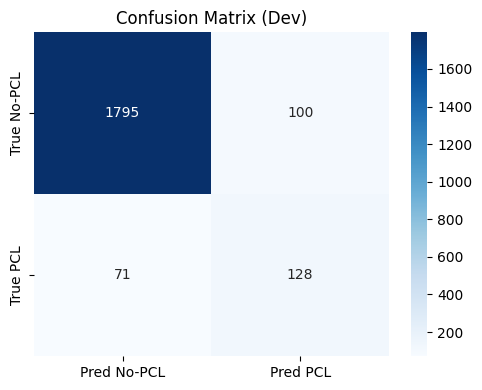

In [ ]:
# ============================================================
# Detailed evaluation report
# ============================================================
pred_output = trainer.predict(dev_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred No-PCL', 'Pred PCL'],
    yticklabels=['True No-PCL', 'True PCL'],
)
plt.title('Confusion Matrix (Dev)')
plt.tight_layout()
plt.savefig("roberta_confusion_matrix.png", dpi=300)
plt.show()


In [ ]:
# ============================================================
# Save best model
# ============================================================
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, 'best')
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

model.mlm.save_pretrained(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

import json
verbalizer_config = {
    'verbalizer': {str(k): v for k, v in VERBALIZER.items()},
    'verbalizer_ids': {str(k): v for k, v in VERBALIZER_IDS.items()},
    'prompt_template': PROMPT_TEMPLATE,
    'mask_token_id': MASK_TOKEN_ID,
}
with open(os.path.join(BEST_MODEL_DIR, 'verbalizer_config.json'), 'w') as f:
    json.dump(verbalizer_config, f, indent=2)

print(f'Saved best model, tokenizer, and verbalizer config to: {BEST_MODEL_DIR}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.00s/it]

Saved best model, tokenizer, and verbalizer config to: checkpoints/roberta_base_prompt_local/best
